+ Mục tiêu của EDA là hiểu dữ liệu để biết:
    + Dữ liệu có bao nhiêu mẫu (samples) và bao nhiêu đặc trưng (features).
    + Kiểu dữ liệu của từng cột (int, float, object, datetime...).
    + Có dữ liệu bị thiếu (Missing Values) hay không.
    + Có dữ liệu trùng lặp (Duplicates) hay không.
    + Phân bố của từng biến như thế nào.
    + Có ngoại lệ (Outliers) hay không.
    + Các đặc trưng có tương quan với nhau ra sao.
    + Đặc trưng nào có ảnh hưởng đến biến mục tiêu (Target).
+ Thống kê mô tả: df.describe()
+ Kiểm tra cấu trúc dữ liệu: df.info()
                           df.shape
                           df.columns
                           df.dtypes
+ Missing value: df.isnull().sum()
+ Phân bố dữ liệu
+ Outliers
+ Mối quan hệ giữa các feature
+ Correlation: df.corr()
+ Phân bố của target: df["Outcome"].value_counts()

Import library

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

Read dataset_cleaning

In [20]:
data = pd.read_csv(r'D:\AI_Projects\Project_1\data\processed\diabetes_clean.csv', sep =';')
data.head()
data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
2424,3,126,88,41,235,39.3,0.704,27,0
2425,4,123,62,0,0,32.0,0.226,35,1
2426,1,80,74,11,60,30.0,0.527,22,0
2427,1,96,64,27,87,33.2,0.289,21,0
2428,6,105,70,32,68,30.8,0.122,37,0


Statistics

In [15]:
data.shape
data.info()
data.describe()
data.describe(include="all")
data.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2429 entries, 0 to 2428
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2429 non-null   int64  
 1   Glucose                   2429 non-null   int64  
 2   BloodPressure             2429 non-null   int64  
 3   SkinThickness             2429 non-null   int64  
 4   Insulin                   2429 non-null   int64  
 5   BMI                       2429 non-null   float64
 6   DiabetesPedigreeFunction  2429 non-null   float64
 7   Age                       2429 non-null   int64  
 8   Outcome                   2429 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 170.9 KB


Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

+ Missing values
    + Nếu có dữ liệu thiếu:
        + Drop
        + Fill Mean
        + Fill Median
        + Fill Mode

In [16]:
data.isnull().sum()
(data.isnull().sum()/len(data))*100

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

Distribution: Phân bố dữ liệu

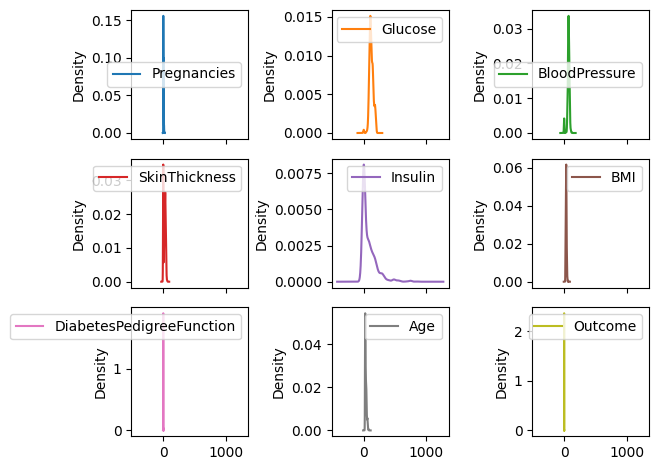

In [18]:
data["Outcome"].value_counts()
data.plot(kind="density", subplots=True, layout=(3,3))
plt.tight_layout()
plt.show()

Phát hiện outliers

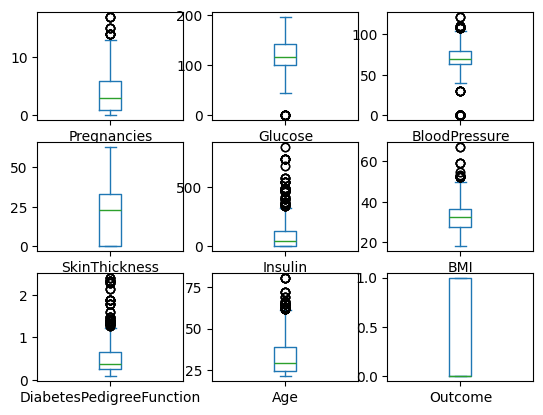

In [19]:
data.plot(kind="box", subplots=True, layout=(3,3))
plt.show()

Correlation: Mục tiêu: Xem các feature liên quan với nhau như thế nào.
Quan sát
    Correlation > 0.8
    Correlation < -0.8
    Multicollinearity

<Axes: >

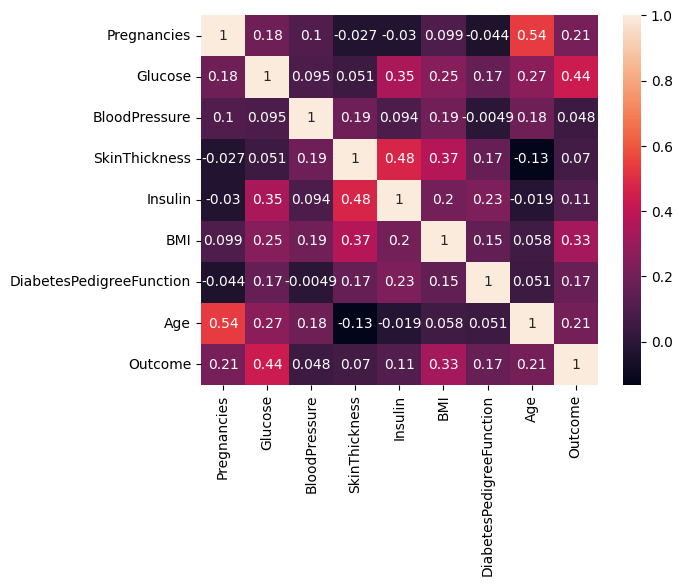

In [21]:
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

Feature Relationships: Mục tiêu: Xem mối quan hệ giữa các feature.

array([[<Axes: xlabel='Pregnancies', ylabel='Pregnancies'>,
        <Axes: xlabel='Glucose', ylabel='Pregnancies'>,
        <Axes: xlabel='BloodPressure', ylabel='Pregnancies'>,
        <Axes: xlabel='SkinThickness', ylabel='Pregnancies'>,
        <Axes: xlabel='Insulin', ylabel='Pregnancies'>,
        <Axes: xlabel='BMI', ylabel='Pregnancies'>,
        <Axes: xlabel='DiabetesPedigreeFunction', ylabel='Pregnancies'>,
        <Axes: xlabel='Age', ylabel='Pregnancies'>,
        <Axes: xlabel='Outcome', ylabel='Pregnancies'>],
       [<Axes: xlabel='Pregnancies', ylabel='Glucose'>,
        <Axes: xlabel='Glucose', ylabel='Glucose'>,
        <Axes: xlabel='BloodPressure', ylabel='Glucose'>,
        <Axes: xlabel='SkinThickness', ylabel='Glucose'>,
        <Axes: xlabel='Insulin', ylabel='Glucose'>,
        <Axes: xlabel='BMI', ylabel='Glucose'>,
        <Axes: xlabel='DiabetesPedigreeFunction', ylabel='Glucose'>,
        <Axes: xlabel='Age', ylabel='Glucose'>,
        <Axes: xlabel='Outcom

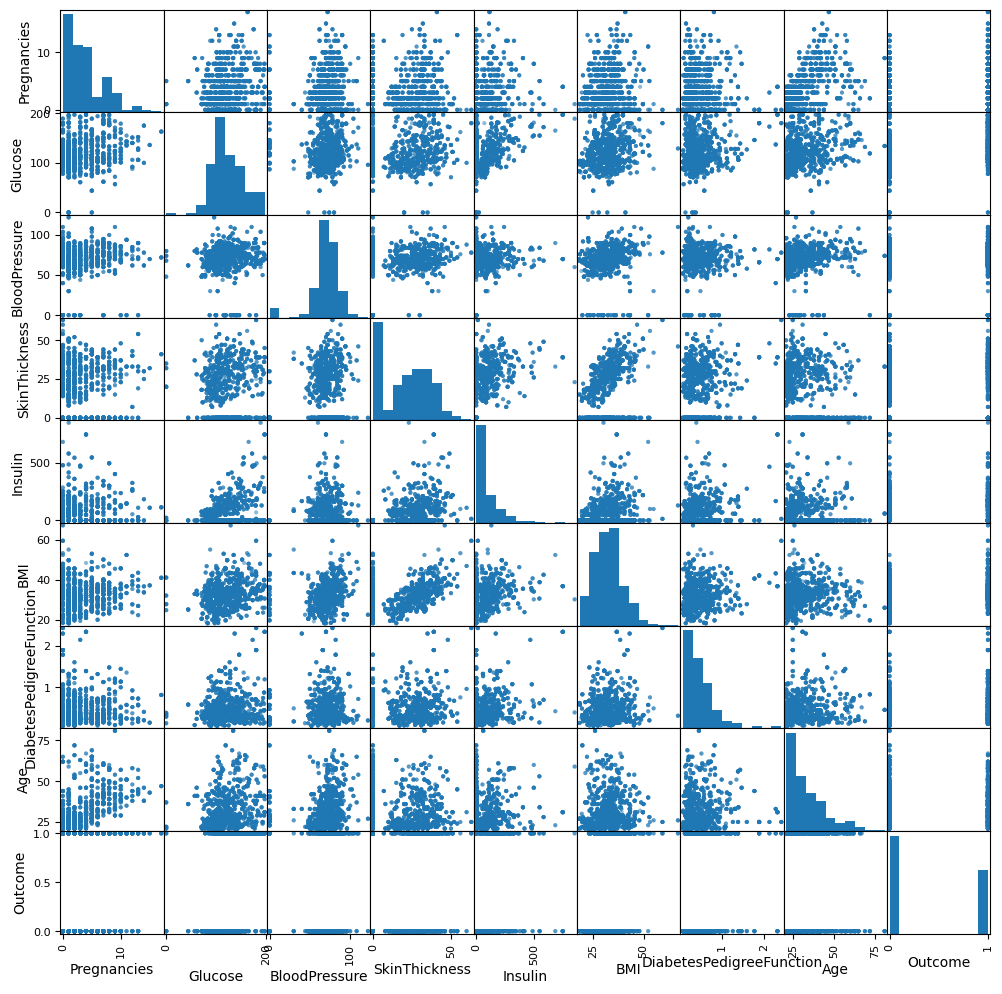

In [23]:
scatter_matrix(data, figsize=(12,12))

Target Analysis

<Axes: xlabel='Outcome', ylabel='count'>

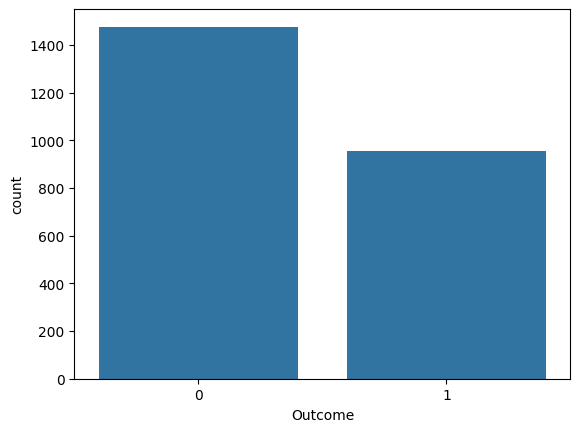

In [24]:
data["Outcome"].value_counts()
sns.countplot(x="Outcome", data=data)